In [75]:
%pip install openneuro-py mne scikit-learn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [76]:
# 01 — Data Exploration
# Load one session, understand the structure, find event markers.


import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from pathlib import Path

mne.set_log_level('WARNING')
%matplotlib inline



GENRE_MAP = {
    1:'Deep House', 2:'Indie', 3:'Electronics', 4:'New Age',
    5:'Electronic Dance', 6:'Ambient', 7:'Hindustani Classical',
    8:'Indian Semi-Classical', 9:'Indian Folk', 10:'Soft Jazz',
    11:'Goth Rock', 12:'Progressive Instrumental Rock'
}
print('MNE:', mne.__version__)

MNE: 1.12.1


In [77]:
# Check Downloaded Files

for sub_dir in sorted(DATA_DIR.glob('sub-*')):
    sets = list(sub_dir.rglob('*.set'))
    print(f'{sub_dir.name}: {len(sets)}/12 sessions')

sub-001: 12/12 sessions
sub-002: 12/12 sessions
sub-003: 12/12 sessions
sub-004: 12/12 sessions
sub-005: 12/12 sessions


In [78]:
#Load One Session (header only) 

if "notebooks" in os.getcwd():
    DATA_DIR = Path('../data/raw')
else:
    DATA_DIR = Path('data/raw')

Path('outputs').mkdir(exist_ok=True)


all_sets = list(DATA_DIR.rglob('*.set'))
if not all_sets:
    print("❌ no .set files")
else:
    set_file = all_sets[0]
    ses_part = [p for p in set_file.parts if 'ses-' in p][0]
    ses_num = int(ses_part.split('-')[1])
    genre = GENRE_MAP[ses_num]

print(f'File : {set_file.name}')
print(f'Genre: {genre}')

raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
print(f'Channels     : {len(raw.ch_names)}')
print(f'Sampling rate: {raw.info["sfreq"]} Hz')
print(f'Duration     : {raw.times[-1]:.1f} s  ({raw.times[-1]/60:.1f} min)')

File : sub-005_ses-04_task-MusicListening_run-4_eeg.set
Genre: New Age


Channels     : 129
Sampling rate: 1000.0 Hz
Duration     : 121.5 s  (2.0 min)


/tmp/ipykernel_11307/982625779.py:23: RuntimeWarning: Omitted 110 annotation(s) that were outside data range.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)
/tmp/ipykernel_11307/982625779.py:23: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(set_file, preload=False, verbose=False)


In [79]:
# Find Event Markers

ann = raw.annotations
print('All event types:')
print(pd.Series(ann.description).value_counts().to_string())

# Look for music start marker
music_markers = ['stm+', 'stim', 'music', 'song']
t_music = None
marker  = None

for m in music_markers:
    mask = np.array([d.lower() == m.lower() for d in ann.description])
    if mask.any():
        t_music = ann.onset[mask][0]
        marker  = ann.description[mask][0]
        break

if t_music is not None:
    print(f'\nMusic start: "{marker}" at {t_music:.2f}s')
else:
    # Last resort: pick the annotation closest to middle of recording
    t_music = raw.times[-1] / 2
    print(f'No marker found — using middle of recording: {t_music:.2f}s')

All event types:
CELL        13
SESS         1
boundary     1
bgin         1
clyp         1
stim         1

Music start: "stim" at 7.49s


In [80]:
# Load Music Segment (30s from stm+)

raw.load_data()
raw_music = raw.copy().crop(tmin=t_music, tmax=t_music + 30.0)
del raw
print(f'Shape: {raw_music.get_data().shape}  (channels x timepoints)')


Shape: (129, 30001)  (channels x timepoints)


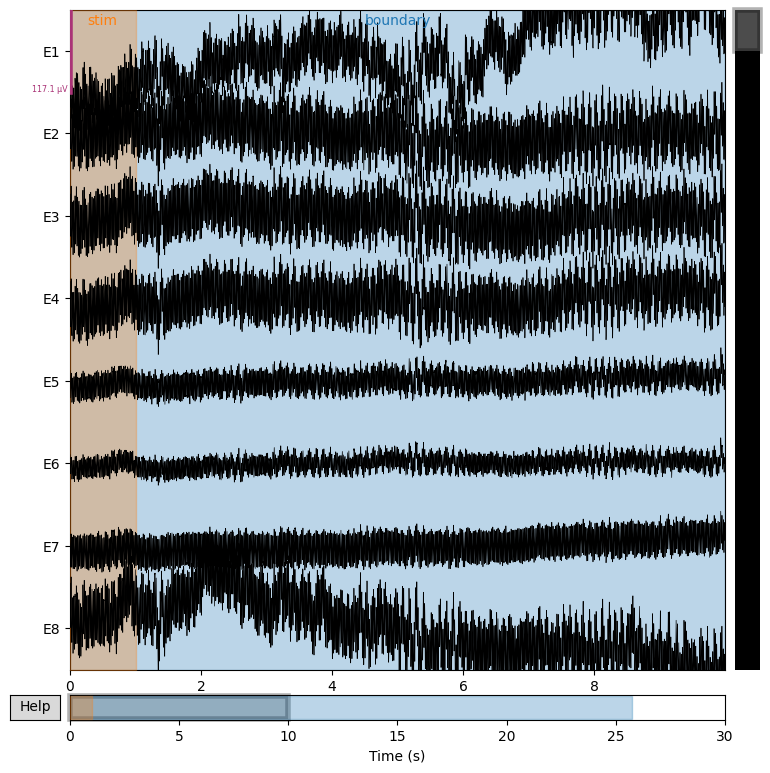

In [81]:
# Raw Signal (8 channels, 10s)

fig = raw_music.plot(duration=10, n_channels=8, scalings='auto',
                     title=f'Raw EEG — {genre}', show=False)

OUTPUT_DIR = Path('../outputs') 
OUTPUT_DIR.mkdir(exist_ok=True)
plt.savefig(OUTPUT_DIR / '01_raw_signal.png', dpi=100, bbox_inches='tight')
plt.show()

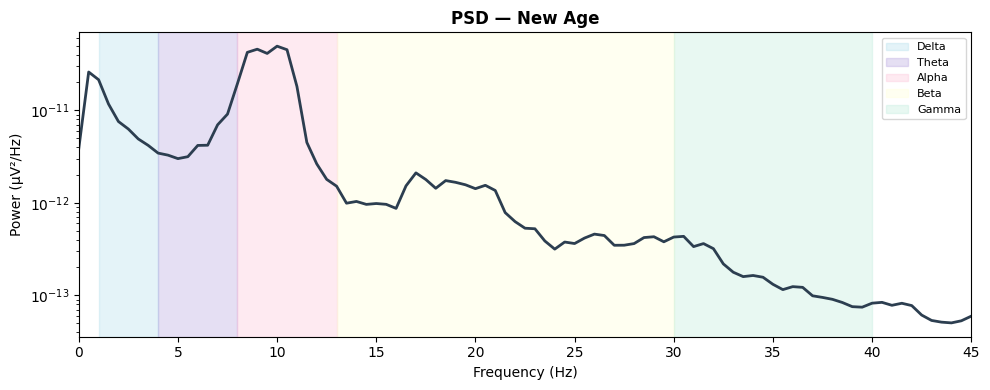

In [82]:
#Power Spectral Density (PSD) of the 30s music segment, averaged across channels. The shaded bands show canonical EEG frequency ranges.

freqs, psd = welch(raw_music.get_data(), fs=raw_music.info['sfreq'],
                   nperseg=int(raw_music.info['sfreq'] * 2))
psd_median = np.median(psd, axis=0)
del psd, raw_music

bands = [('Delta',1,4,'#a8d8ea'),('Theta',4,8,'#aa96da'),
         ('Alpha',8,13,'#fcbad3'),('Beta',13,30,'#ffffd2'),('Gamma',30,40,'#b5ead7')]

fig, ax = plt.subplots(figsize=(10,4))
mask = freqs <= 45
ax.semilogy(freqs[mask], psd_median[mask], color='#2c3e50', lw=2)
for name, lo, hi, color in bands:
    ax.axvspan(lo, hi, alpha=0.3, color=color, label=name)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (μV²/Hz)')
ax.set_title(f'PSD — {genre}', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xlim(0, 45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_raw_signal.png', dpi=100)


OUTPUT_DIR = Path('../outputs') 
OUTPUT_DIR.mkdir(exist_ok=True)

# Kaydederken de bunu kullan:
plt.savefig(OUTPUT_DIR / '01_psd.png')
plt.show()